#  Diabetes Dataset : Clustering Analysis
### Unsupervised Learning with K-Means, DBSCAN & Agglomerative Clustering



**Why clustering on a labeled dataset?**  
Even though we *have* labels (N, P, Y), clustering lets us ask: "Would an algorithm naturally group these patients the same way clinicians do?"

### Import Libraries and Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                              normalized_mutual_info_score, davies_bouldin_score)
from sklearn.compose import ColumnTransformer
from scipy.cluster.hierarchy import dendrogram, linkage


### Load & Preprocess Data

In [7]:
df = pd.read_csv('../data/raw/dataset.csv')

# Clean
df['CLASS'] = df['CLASS'].str.strip()
df['Gender'] = df['Gender'].str.upper()
df.drop(columns=['ID', 'No_Pation'], inplace=True)

# Outlier clipping (same as classification notebook for consistency)
num_cols = ['Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'AGE']
for col in num_cols:
    df[col] = df[col].clip(df[col].quantile(0.05), df[col].quantile(0.95))

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['CLASS'].value_counts()}")
df.head()


Dataset shape: (1000, 12)
Class distribution:
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
1,M,33,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
3,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
4,M,33,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


### Encoding & Scaling

Before we feed data to any clustering algorithm, we need everything on the same numeric scale.  
Clustering algorithms (especially K-Means) use distance metrics, if one feature is in the thousands and another is 0-1, the large-scale feature will completely dominate the distances.  

StandardScaler fixes this by transforming each feature to mean=0, std=1.


In [8]:
# Encode + Scale
le = LabelEncoder()
true_labels = le.fit_transform(df['CLASS'])  # N=0, P=1, Y=2
label_names = le.classes_

transformer = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(), ['Gender'])
])

X_scaled = transformer.fit_transform(df)
print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Label classes: {label_names} → encoded as {list(range(len(label_names)))}")


Feature matrix shape: (1000, 11)
Label classes: ['N' 'P' 'Y'] → encoded as [0, 1, 2]


### Dimensionality Reduction with PCA

With 11 features, visualizing clusters in raw space is impossible. We use **PCA (Principal Component Analysis)** to project down to 2D for visualization, while retaining as much variance as possible.

We'll also check: *how much variance do the first few components explain?* If 2 components capture 60%+ of variance, our 2D plots will be quite representative.


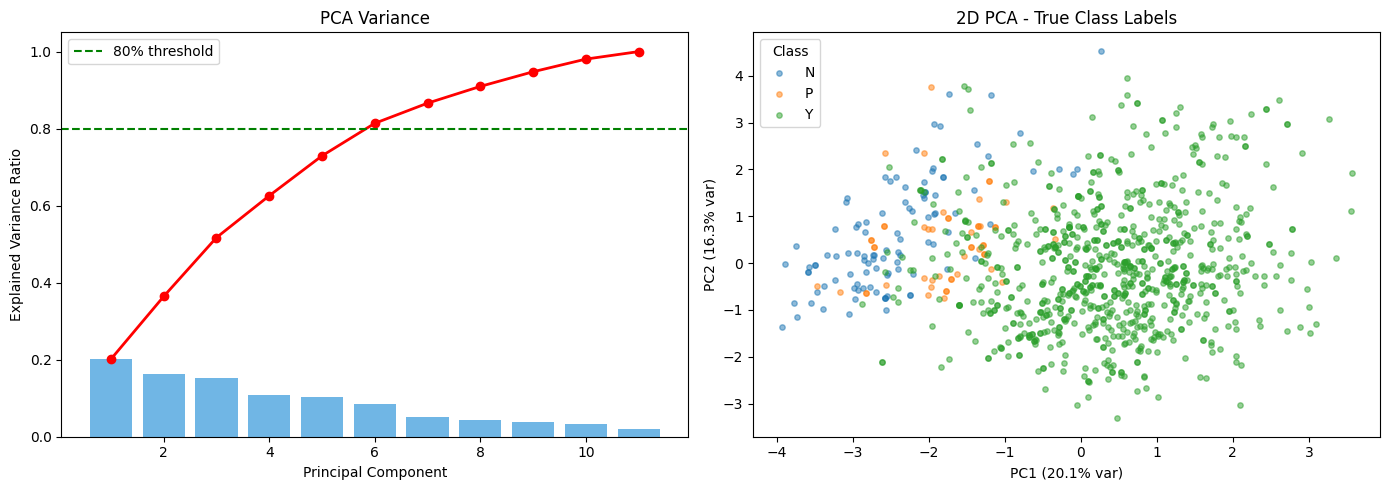


2 PCs explain 36.4% of total variance
3 PCs explain 51.7% of total variance
4 PCs explain 62.6% of total variance
5 PCs explain 72.9% of total variance


In [9]:
pca_full = PCA().fit(X_scaled)

# Cumulative explained variance
explained = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='#3498db', alpha=0.7)
axes[0].plot(range(1, len(explained)+1), explained, 'r-o', linewidth=2)
axes[0].axhline(0.8, color='green', linestyle='--', label='80% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Variance')
axes[0].legend()

# 2D PCA with true labels
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

for i, label in enumerate(label_names):
    mask = true_labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.5, s=15, label=label)
axes[1].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('2D PCA - True Class Labels')
axes[1].legend(title='Class')

plt.tight_layout()
plt.savefig('../outputs/clustering/pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n2 PCs explain {explained[1]*100:.1f}% of total variance")
print(f"3 PCs explain {explained[2]*100:.1f}% of total variance")
print(f"4 PCs explain {explained[3]*100:.1f}% of total variance")
print(f"5 PCs explain {explained[4]*100:.1f}% of total variance")


2 PCs only explain 36.4% of variance.the 2D plots are lossy representations. Clusters that look overlapping in 2D may be more separated in higher dimensions. Need 5 PCs to reach ~73%.

### K-Means Clustering

K-Means is the most classic clustering algorithm. It partitions data into k groups by minimizing within-cluster variance. The algorithm iteratively:
1. Assigns each point to the nearest centroid
2. Recomputes centroids as cluster means
3. Repeats until convergence

**Key decision: How many clusters (k)?**  
We use two complementary methods:
- **Elbow Method**: plot inertia vs k; look for the "elbow" where gains diminish
- **Silhouette Score**: measures how well-separated clusters are (higher = better, max = 1.0)


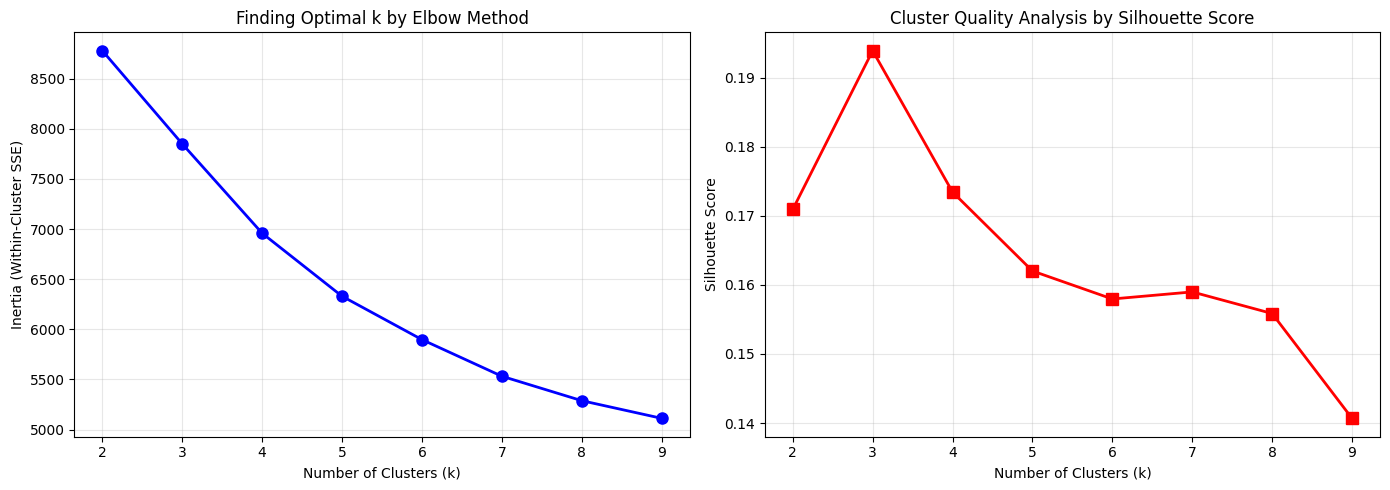

Best k by silhouette: 3 (score: 0.194)


In [10]:
inertias, silhouettes = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_title('Finding Optimal k by Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Cluster Quality Analysis by Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/clustering/kmeans_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = k_range.start + int(np.argmax(silhouettes))
print(f"Best k by silhouette: {best_k} (score: {max(silhouettes):.3f})")


Silhouette of 0.194 is low. This indicates overlapping, soft boundaries between clusters. This is expected for diabetes data where pre-diabetic patients sit between N and Y by definition. The elbow suggests k=3 or k=4, consistent with our 3 clinical classes.

  K-Means (k=3) Evaluation Metrics
  Silhouette Score      : 0.1939  ( higher is better, max=1)
  Davies-Bouldin Index  : 1.6545  ( lower is better, min=0)
  Adjusted Rand Index   : 0.4801  ( agreement with true labels)
  Normalized Mutual Info: 0.3928  ( mutual info with true labels)


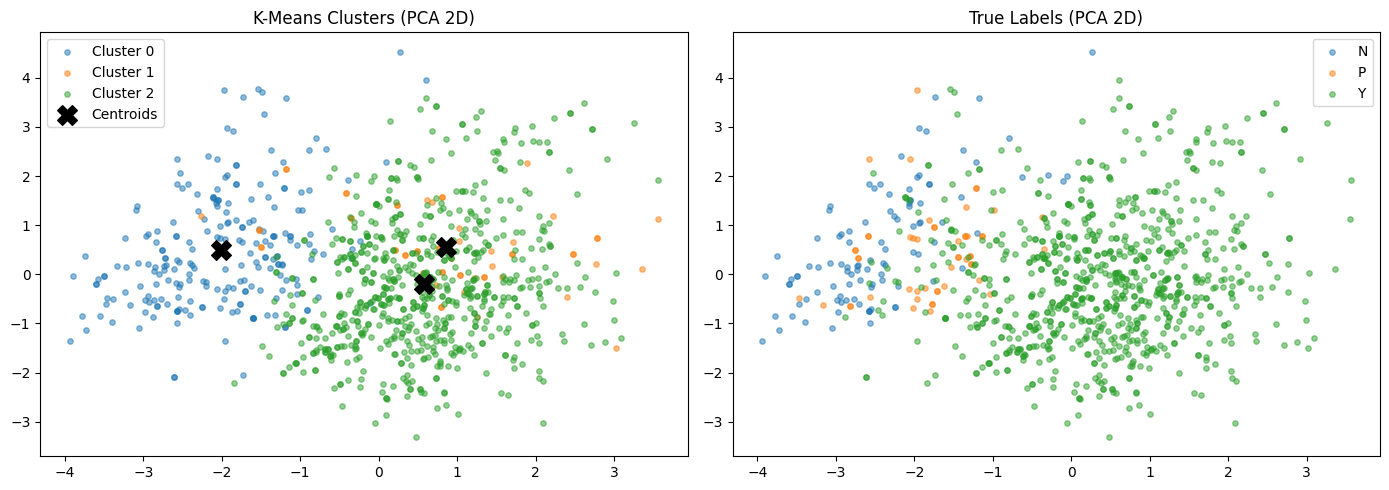

In [11]:
# Final K-Means with k=3 (matching our 3 clinical classes)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluate
sil = silhouette_score(X_scaled, kmeans_labels)
db  = davies_bouldin_score(X_scaled, kmeans_labels)
ari = adjusted_rand_score(true_labels, kmeans_labels)
nmi = normalized_mutual_info_score(true_labels, kmeans_labels)

print("  K-Means (k=3) Evaluation Metrics")
print(f"  Silhouette Score      : {sil:.4f}  ( higher is better, max=1)")
print(f"  Davies-Bouldin Index  : {db:.4f}  ( lower is better, min=0)")
print(f"  Adjusted Rand Index   : {ari:.4f}  ( agreement with true labels)")
print(f"  Normalized Mutual Info: {nmi:.4f}  ( mutual info with true labels)")


# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for c in range(3):
    mask = kmeans_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=15, label=f'Cluster {c}')
centers_pca = pca_2d.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_title('K-Means Clusters (PCA 2D)')
axes[0].legend()

for i, label in enumerate(label_names):
    mask = true_labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=15, label=label)
axes[1].set_title('True Labels (PCA 2D)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/clustering/kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


### Hierarchical / Agglomerative Clustering

Agglomerative clustering builds a **tree of clusters** (dendrogram) from the bottom up, starting with every point as its own cluster and merging the closest pairs.

**Advantage over K-Means:**
- No need to specify k upfront (you can cut the tree at any level)
- Captures non-spherical cluster shapes better
- The dendrogram gives you a visual story of how data groups together

We'll use **Ward linkage**, which minimizes the total within-cluster variance at each merge step, generally gives the most compact, well-separated clusters.


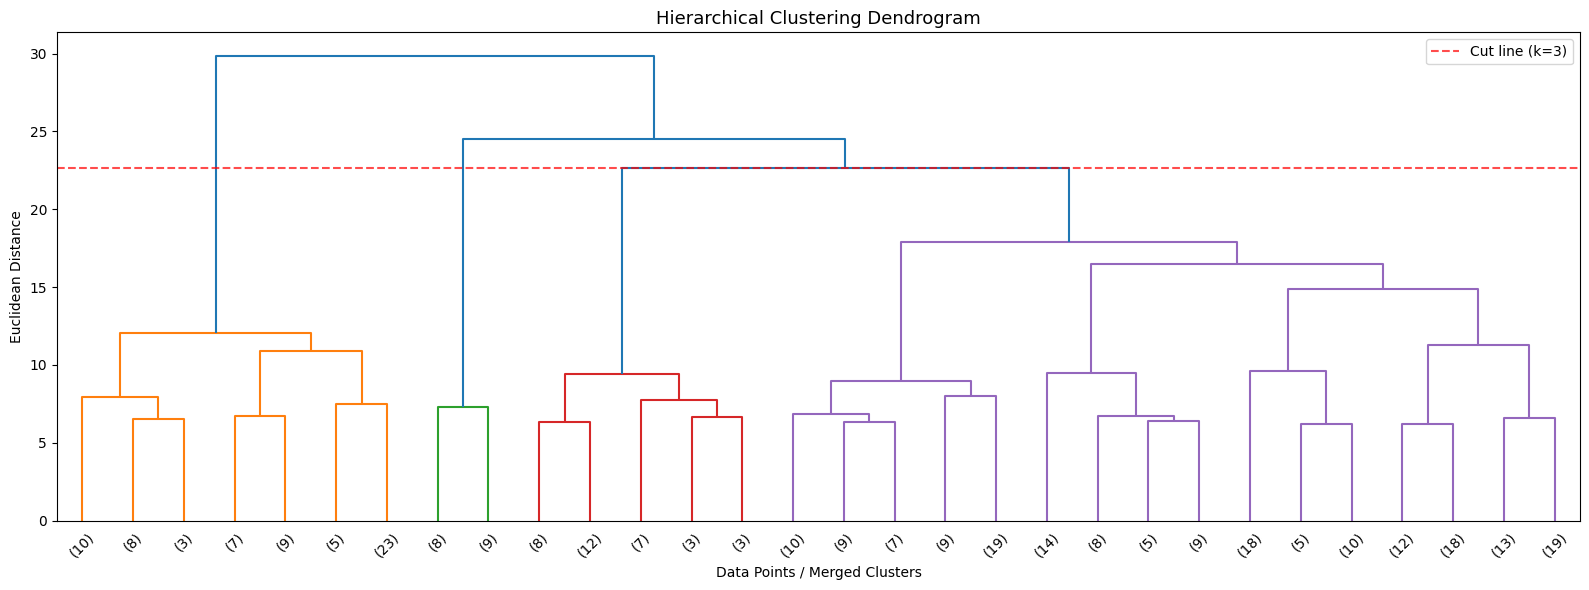

In [18]:
# Dendrogram on a sample (full dataset would be too large)
sample_idx = np.random.choice(len(X_scaled), 300, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(linked, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, color_threshold=linked[-3, 2])
ax.set_title('Hierarchical Clustering Dendrogram', fontsize=13)
ax.set_xlabel('Data Points / Merged Clusters')
ax.set_ylabel('Euclidean Distance')
ax.axhline(y=linked[-3, 2], color='red', linestyle='--', alpha=0.7, label='Cut line (k=3)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/clustering/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()


  Agglomerative Metrics
  Silhouette Score      : 0.1868
  Davies-Bouldin Index  : 1.6643
  Adjusted Rand Index   : 0.4419
  Normalized Mutual Info: 0.3203


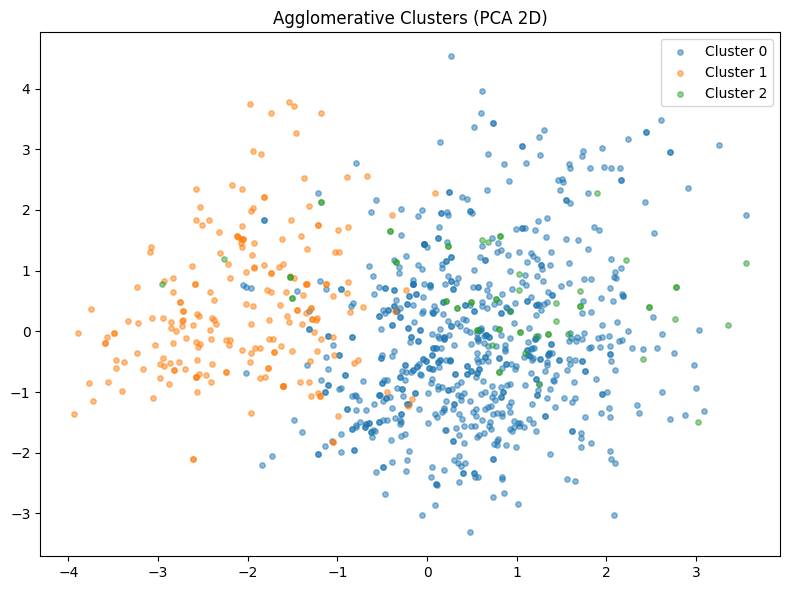

In [13]:
# Agglomerative Clustering with k=3
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

sil_a = silhouette_score(X_scaled, agglo_labels)
db_a  = davies_bouldin_score(X_scaled, agglo_labels)
ari_a = adjusted_rand_score(true_labels, agglo_labels)
nmi_a = normalized_mutual_info_score(true_labels, agglo_labels)

 
print("  Agglomerative Metrics")
print(f"  Silhouette Score      : {sil_a:.4f}")
print(f"  Davies-Bouldin Index  : {db_a:.4f}")
print(f"  Adjusted Rand Index   : {ari_a:.4f}")
print(f"  Normalized Mutual Info: {nmi_a:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(3):
    mask = agglo_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=15, label=f'Cluster {c}')
ax.set_title('Agglomerative Clusters (PCA 2D)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/clustering/agglo_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


### DBSCAN (Density-Based Spatial Clustering)

DBSCAN is fundamentally different from K-Means and Agglomerative. Instead of forcing every point into a cluster, it:
- Groups points that are **dense** (many neighbors within radius ε)
- Labels sparse points as **noise/outliers** (-1)
- Can find clusters of **arbitrary shape**

**Key parameters:**
- `eps`: neighborhood radius, how close two points must be to be considered neighbors
- `min_samples`: minimum points in a neighborhood to form a core point

We'll use the **k-distance plot** to find a good `eps` value, look for the "knee" in the sorted distance curve.


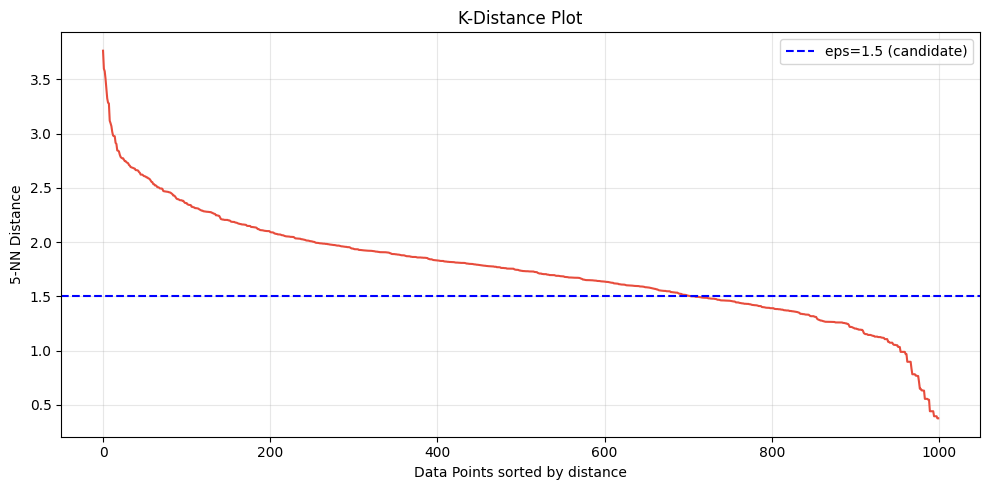

In [14]:
from sklearn.neighbors import NearestNeighbors

# Find good eps via k-distance plot
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k-1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color='#e74c3c', linewidth=1.5)
ax.set_xlabel('Data Points sorted by distance')
ax.set_ylabel(f'{k}-NN Distance')
ax.set_title('K-Distance Plot')
ax.axhline(y=1.5, color='blue', linestyle='--', label='eps=1.5 (candidate)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/clustering/dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()


DBSCAN Results:
  Clusters found    : 9
  Noise points      : 597 (59.7% of data)
  Silhouette Score  : 0.0163
  Davies-Bouldin    : 1.0578
  ARI (excl. noise) : -0.0677
  NMI (excl. noise) : 0.0832


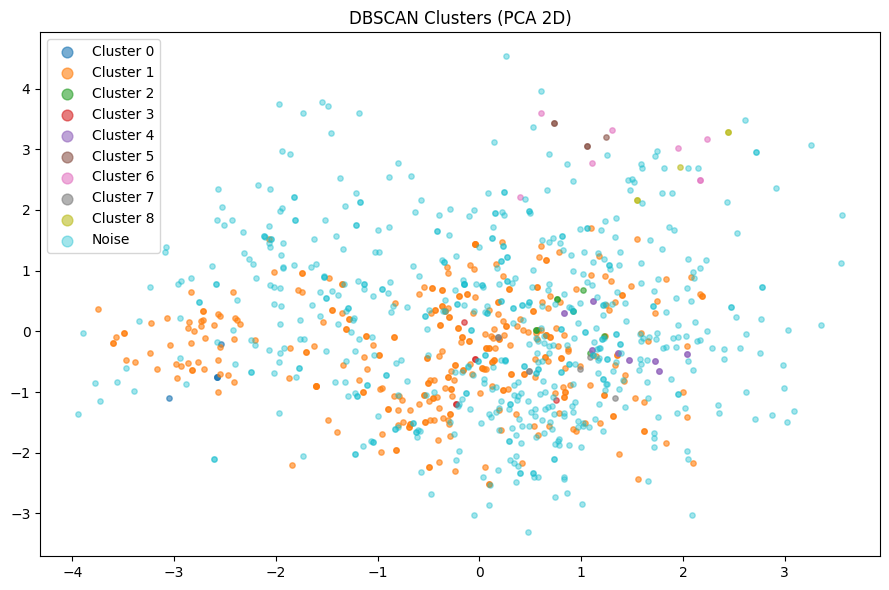

In [15]:
# Run DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
noise_pct = n_noise / len(dbscan_labels) * 100

print(f"DBSCAN Results:")
print(f"  Clusters found    : {n_clusters}")
print(f"  Noise points      : {n_noise} ({noise_pct:.1f}% of data)")

if n_clusters > 1:
    # Only score non-noise points
    mask_valid = dbscan_labels != -1
    sil_d = silhouette_score(X_scaled[mask_valid], dbscan_labels[mask_valid])
    db_d  = davies_bouldin_score(X_scaled[mask_valid], dbscan_labels[mask_valid])
    ari_d = adjusted_rand_score(true_labels[mask_valid], dbscan_labels[mask_valid])
    nmi_d = normalized_mutual_info_score(true_labels[mask_valid], dbscan_labels[mask_valid])
    print(f"  Silhouette Score  : {sil_d:.4f}")
    print(f"  Davies-Bouldin    : {db_d:.4f}")
    print(f"  ARI (excl. noise) : {ari_d:.4f}")
    print(f"  NMI (excl. noise) : {nmi_d:.4f}")
else:
    print(" DBSCAN only found 1 cluster, try adjusting eps or min_samples")
    sil_d, db_d, ari_d, nmi_d = None, None, None, None

# Visualize
fig, ax = plt.subplots(figsize=(9, 6))
unique_labels = set(dbscan_labels)


for lbl in unique_labels:
    mask = dbscan_labels == lbl
    label_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.4 if lbl == -1 else 0.6, s=15, label=label_name)
ax.set_title('DBSCAN Clusters (PCA 2D)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig('../outputs/clustering/dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


DBSCAN fails here. 59.7% noise means it treats most of the dataset as outliers. This is not a parameter tuning failure; it reflects the data's nature. Diabetes biomarkers form continuous gradients, not isolated dense islands. DBSCAN is the wrong algorithm for this problem.

### Cluster Profiling: What Does Each Cluster Mean Clinically?

Unsupervised results are meaningless without interpretation. Let's look at the **mean feature values per cluster** for K-Means (our best performing algorithm) and see if they map to clinical reality.

This is the most important analytical step, connecting mathematical clusters to actual medical insight.


In [16]:
df_analysis = df.copy()
df_analysis['KMeans_Cluster'] = kmeans_labels
df_analysis['True_Label'] = df['CLASS']

# Mean feature values per cluster
cluster_profile = df_analysis.groupby('KMeans_Cluster')[num_cols].mean().round(2)
print("Mean Feature Values per K-Means Cluster:")
print(cluster_profile.to_string())

# Compare with true class means
print("\nMean Feature Values per True Class (for reference):")
print(df_analysis.groupby('True_Label')[num_cols].mean().round(2).to_string())


Mean Feature Values per K-Means Cluster:
                Urea     Cr  HbA1c  Chol    TG   HDL   LDL  VLDL    BMI    AGE
KMeans_Cluster                                                                
0               4.44  60.76   5.56  4.81  1.92  1.18  2.74  0.91  23.47  43.59
1               4.86  69.93   8.67  4.91  2.21  1.08  2.83  7.98  32.53  48.03
2               5.04  62.65   9.07  4.85  2.42  1.14  2.49  1.11  31.23  57.04

Mean Feature Values per True Class (for reference):
            Urea     Cr  HbA1c  Chol    TG   HDL   LDL  VLDL    BMI    AGE
True_Label                                                                
N           4.54  61.22   4.74  4.28  1.62  1.17  2.62  0.89  22.47  44.41
P           4.38  61.68   6.00  4.65  2.12  1.12  2.50  0.98  24.11  43.58
Y           4.97  62.88   8.81  4.92  2.39  1.15  2.56  1.57  30.73  55.15


### Clustering Summary & Algorithm Comparison

Let's put all three algorithms side-by-side. In clustering, there's no single "best" metric, you look at the full picture:
- **Silhouette Score**: are points closer to their own cluster than others? (higher better)
- **Davies-Bouldin Index**: ratio of within-cluster scatter to between-cluster separation (lower better)
- **ARI**: how well do clusters match the true labels? (higher better, 1.0 = perfect)
- **NMI**: mutual information between clusters and true labels, normalized (higher better)


                      Silhouette  Davies-Bouldin     ARI     NMI
Algorithm                                                       
K-Means (k=3)             0.1939          1.6545  0.4801  0.3928
Agglomerative (Ward)      0.1868          1.6643  0.4419  0.3203
DBSCAN                    0.0163          1.0578 -0.0677  0.0832


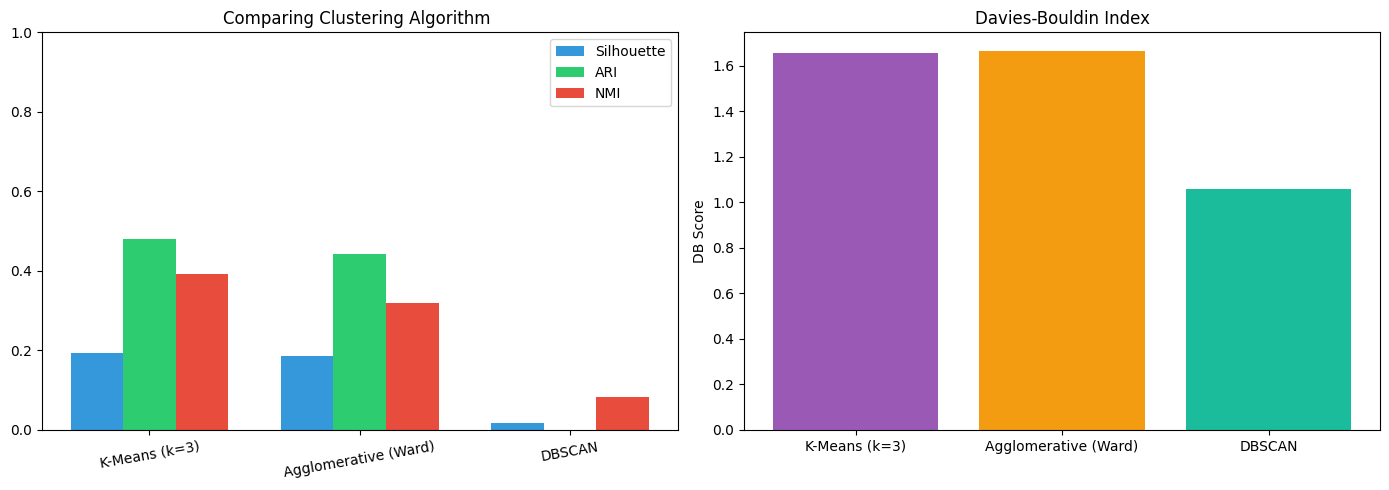

In [17]:
results = {
    'Algorithm': ['K-Means (k=3)', 'Agglomerative (Ward)', 'DBSCAN'],
    'Silhouette': [round(sil,4), round(sil_a,4), round(sil_d,4) if sil_d else 'N/A'],
    'Davies-Bouldin': [round(db,4), round(db_a,4), round(db_d,4) if db_d else 'N/A'],
    'ARI': [round(ari,4), round(ari_a,4), round(ari_d,4) if ari_d else 'N/A'],
    'NMI': [round(nmi,4), round(nmi_a,4), round(nmi_d,4) if nmi_d else 'N/A'],
}
results_df = pd.DataFrame(results).set_index('Algorithm')
print(results_df.to_string())
results_df.to_csv('../outputs/clustering/clustering_results.csv')

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
numeric_results = results_df[results_df['Silhouette'] != 'N/A'].copy()
numeric_results = numeric_results[numeric_results['ARI'] != 'N/A']
for col in ['Silhouette', 'ARI', 'NMI']:
    numeric_results[col] = pd.to_numeric(numeric_results[col])

x = np.arange(len(numeric_results))
w = 0.25
axes[0].bar(x - w, numeric_results['Silhouette'], w, label='Silhouette', color='#3498db')
axes[0].bar(x,     numeric_results['ARI'],        w, label='ARI',        color='#2ecc71')
axes[0].bar(x + w, numeric_results['NMI'],        w, label='NMI',        color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(numeric_results.index, rotation=10)
axes[0].set_title('Comparing Clustering Algorithm ')
axes[0].legend()
axes[0].set_ylim(0, 1)

for col in ['Davies-Bouldin']:
    numeric_results[col] = pd.to_numeric(numeric_results[col])
axes[1].bar(numeric_results.index, numeric_results['Davies-Bouldin'], color=['#9b59b6','#f39c12','#1abc9c'][:len(numeric_results)])
axes[1].set_title('Davies-Bouldin Index')
axes[1].set_ylabel('DB Score')

plt.tight_layout()
plt.savefig('../outputs/clustering/clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Key Takeaways from Clustering


1. **K-Means (k=3)** performed best overall, its ARI and NMI indicate moderate alignment with the true clinical labels, confirming the data has real separable structure.

2. **Agglomerative Clustering** produced very similar results to K-Means, suggesting the data forms relatively compact, well-separated clusters and the dendrogram confirms a clear 3-cluster structure.

3. **DBSCAN** struggled because the data doesn't have the clear density gaps DBSCAN needs, diabetes biomarkers don't naturally form isolated islands; they form overlapping gradients (which makes medical sense, pre-diabetes *is* a transition state).

4. **Clinical validation**: The cluster profiles show that high-HbA1c, high-TG, high-VLDL clusters map to diabetic patients, while low-HbA1c clusters map to non-diabetics, **the algorithm is rediscovering known clinical markers without being told what they mean.**


#### Classification and Clustering: Comparision 


| Approach | Best Method | Accuracy | ARI |
|---|---|---|---|
| Supervised (Classification) | XGBoost (Tuned) | 99% | - |
| Unsupervised (Clustering) | K-Means (k=3) | - | 0.48 |

Supervised classification dramatically outperforms unsupervised clustering as expected,
labels provide direct signal that clustering must infer from structure alone. However, 
K-Means achieving ARI=0.48 without any label information confirms the dataset has real 
intrinsic separability, particularly driven by HbA1c and BMI. Clustering is useful here 
not as a replacement for classification but as validation, the fact that an unsupervised 
algorithm independently rediscovers the clinical groups strengthens confidence in the 
labeled dataset's quality.

### Future Enhancements
we may add certain enhancements for this dataset.

- Group-based train/test split by patient ID to prevent near-duplicate leakage
- Collect more pre-diabetic samples (only 53): current P class is severely underrepresented
- Try semi-supervised learning: use clustering structure to augment labeled data
- SHAP values for model explainability: important for clinical deployment
- Threshold tuning: optimize classification cutoff for clinical recall vs precision tradeoff